# test.png ile HSVColorClassifier Adim Adim Canli Test

Bu notebook, `src/robolig_ai/color/hsv_classifier.py` akisindaki tum adimlari tek tek gosterir.
Girdi olarak `src/robolig_ai/color/test.png` kullanilir.

## 1) Calisma Ortami ve Importlar

Gerekli paketleri import eder, proje kokunu `sys.path` uzerinden baglar ve logger seviyesini DEBUG yapar.

In [ ]:
import sys
import logging
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Notebook konumu: <repo>/notebooks/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.DEBUG, format="[%(levelname)s] %(message)s")
logger = logging.getLogger("hsv-notebook")
logger.setLevel(logging.DEBUG)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")

## 2) test.png Yukleme ve Ilk Gorsellestirme

`test.png` yuklenir, BGR->RGB donusumu yapilir ve goruntu boyutu yazdirilir.

In [ ]:
TEST_IMAGE_PATH = PROJECT_ROOT / "src" / "robolig_ai" / "color" / "test.png"

if not TEST_IMAGE_PATH.exists():
    raise FileNotFoundError(f"test.png bulunamadi: {TEST_IMAGE_PATH}")

image_bgr = cv2.imread(str(TEST_IMAGE_PATH))
if image_bgr is None:
    raise RuntimeError("OpenCV resmi okuyamadi. Dosya bozuk olabilir.")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w = image_bgr.shape[:2]

print(f"Goruntu yolu: {TEST_IMAGE_PATH}")
print(f"Goruntu boyutu: {w}x{h}")

plt.figure(figsize=(7, 5))
plt.title("test.png (RGB)")
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

## 3) BoundingBox ve Ornek Renk Araliklari Tanimi

Test goruntusu icin bir bounding box tanimlanir. HSV renk araliklari ornek olarak girilir (kirmizi icin cift aralik dahil).

BBox: BoundingBox(x1=480, y1=216, x2=1440, y2=918)


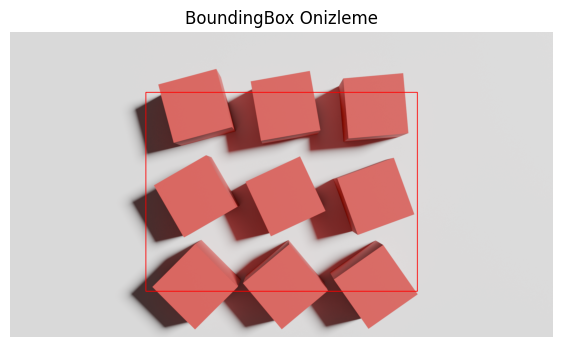

In [3]:
from robolig_ai.utils.types import BoundingBox

# Manuel bbox: isterseniz burayi degistirin
bbox = BoundingBox(
    x1=int(w * 0.25),
    y1=int(h * 0.20),
    x2=int(w * 0.75),
    y2=int(h * 0.85),
)

# OpenCV HSV uzayi: H 0-179, S 0-255, V 0-255
color_ranges = {
    "red": {
        "lower1": [0, 80, 60], "upper1": [10, 255, 255],
        "lower2": [170, 80, 60], "upper2": [179, 255, 255],
    },
    "blue": {
        "lower": [95, 80, 60], "upper": [130, 255, 255],
    },
    "green": {
        "lower": [35, 60, 50], "upper": [90, 255, 255],
    },
    "yellow": {
        "lower": [15, 80, 80], "upper": [35, 255, 255],
    },
}

print("BBox:", bbox)
preview = image_rgb.copy()
cv2.rectangle(preview, (bbox.x1, bbox.y1), (bbox.x2, bbox.y2), (255, 0, 0), 2)
plt.figure(figsize=(7, 5))
plt.title("BoundingBox Onizleme")
plt.imshow(preview)
plt.axis("off")
plt.show()

## 4) HSVColorClassifier Nesnesi Olusturma

Parametreleri hucre degiskenleri olarak tanimlayip siniflandirici nesnesini olusturuyoruz.

In [4]:
from robolig_ai.color.hsv_classifier import HSVColorClassifier
from robolig_ai.color.normalization import apply_clahe, extract_roi_center, compute_dominant_hsv

use_center_region = True
center_region_ratio = 0.6
apply_clahe_preprocessing = True
clahe_clip_limit = 2.0
clahe_grid_size = 8
min_saturation = 30
min_value = 30
min_pixel_ratio = 0.1

classifier = HSVColorClassifier(
    color_ranges=color_ranges,
    use_center_region=use_center_region,
    center_region_ratio=center_region_ratio,
    apply_clahe_preprocessing=apply_clahe_preprocessing,
    clahe_clip_limit=clahe_clip_limit,
    clahe_grid_size=clahe_grid_size,
    min_saturation=min_saturation,
    min_value=min_value,
    min_pixel_ratio=min_pixel_ratio,
)

print("Classifier hazir.")

Classifier hazir.


## 5) ROI Cikarma (Tam Kutu vs Merkez Bolge)

Ayni bbox icin tam ROI ve merkez ROI yan yana gosterilir.

Tam ROI boyutu: 960x702
Merkez ROI boyutu: 576x421


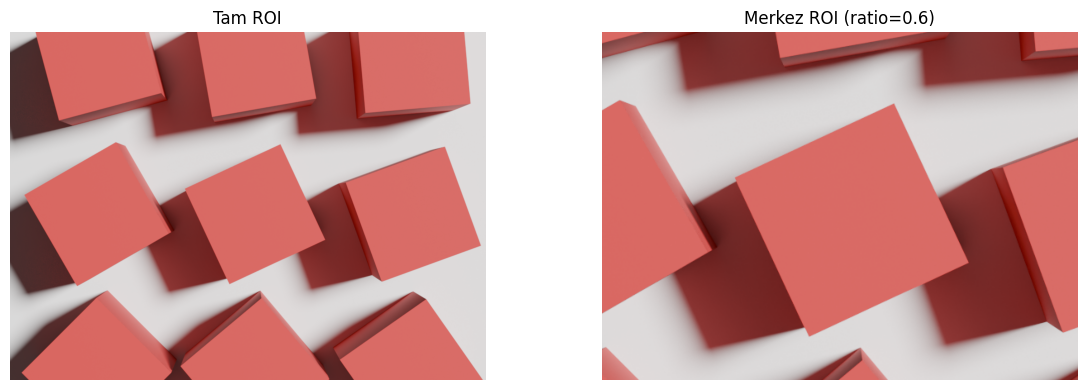

In [5]:
roi_full = image_bgr[bbox.y1:bbox.y2, bbox.x1:bbox.x2]
roi_center = extract_roi_center(
    image_bgr, bbox.x1, bbox.y1, bbox.x2, bbox.y2, center_region_ratio
)

print(f"Tam ROI boyutu: {roi_full.shape[1]}x{roi_full.shape[0]}")
print(f"Merkez ROI boyutu: {roi_center.shape[1]}x{roi_center.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(roi_full, cv2.COLOR_BGR2RGB))
axes[0].set_title("Tam ROI")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(roi_center, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Merkez ROI (ratio={center_region_ratio})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 6) CLAHE On Isleme Etkisini Gorsellestirme

Ayni ROI icin CLAHE kapali/acik karsilastirmasi yapilir ve kisa metrikler yazdirilir.

Ortalama BGR (oncesi): [127.07 129.55 190.48]
Ortalama BGR (sonrasi): [127.1  129.41 190.07]
Std BGR (oncesi): [67.54 66.19 40.45]
Std BGR (sonrasi): [70.98 69.86 45.7 ]


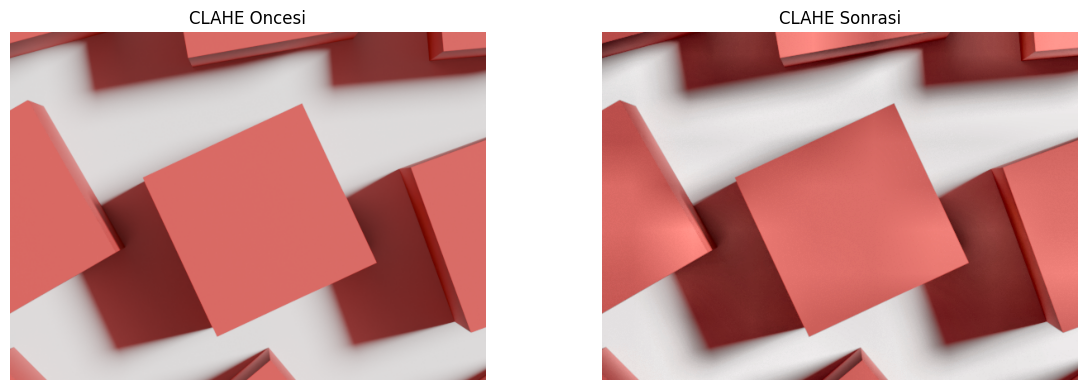

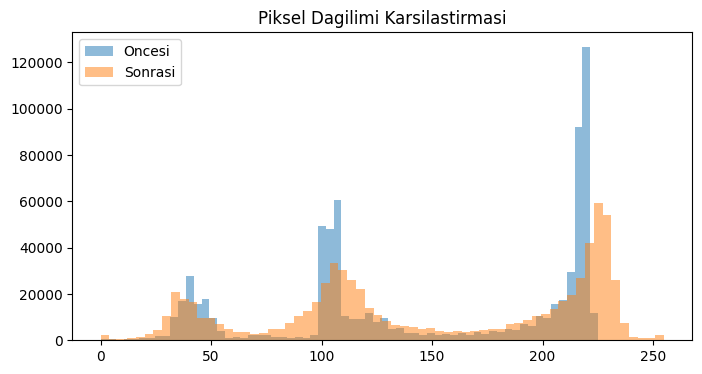

In [6]:
roi_before = roi_center.copy()
roi_after = apply_clahe(roi_before, clip_limit=clahe_clip_limit, grid_size=clahe_grid_size)

before_mean = roi_before.mean(axis=(0, 1))
after_mean = roi_after.mean(axis=(0, 1))
before_std = roi_before.std(axis=(0, 1))
after_std = roi_after.std(axis=(0, 1))

print("Ortalama BGR (oncesi):", np.round(before_mean, 2))
print("Ortalama BGR (sonrasi):", np.round(after_mean, 2))
print("Std BGR (oncesi):", np.round(before_std, 2))
print("Std BGR (sonrasi):", np.round(after_std, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(roi_before, cv2.COLOR_BGR2RGB))
axes[0].set_title("CLAHE Oncesi")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(roi_after, cv2.COLOR_BGR2RGB))
axes[1].set_title("CLAHE Sonrasi")
axes[1].axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(roi_before.ravel(), bins=64, alpha=0.5, label="Oncesi")
plt.hist(roi_after.ravel(), bins=64, alpha=0.5, label="Sonrasi")
plt.title("Piksel Dagilimi Karsilastirmasi")
plt.legend()
plt.show()

## 7) HSV Donusumu ve Baskin HSV Hesabi

ROI HSV uzayina cevrilir, dominant HSV hesaplanir ve min sat/value esikleri kontrol edilir.

Dominant HSV -> H: 25.73, S: 94.49, V: 190.07
Doygunluk/parlaklik esik kontrolu gecti


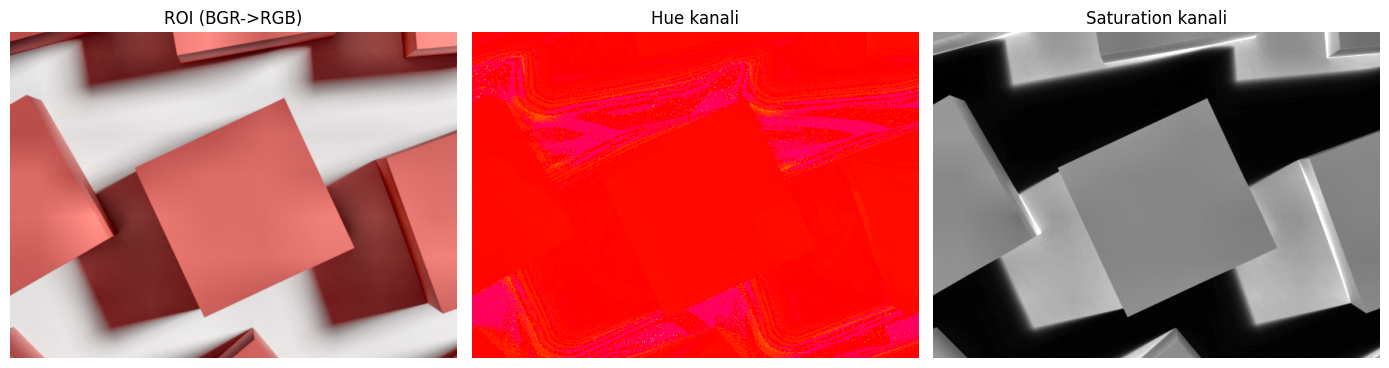

In [7]:
hsv_roi = cv2.cvtColor(roi_after, cv2.COLOR_BGR2HSV)
dominant_h, dominant_s, dominant_v = compute_dominant_hsv(hsv_roi)

print(f"Dominant HSV -> H: {dominant_h:.2f}, S: {dominant_s:.2f}, V: {dominant_v:.2f}")
if dominant_s < min_saturation or dominant_v < min_value:
    print("Uyari: Doygunluk/parlaklik esik altinda -> UNKNOWN olasiligi yuksek")
else:
    print("Doygunluk/parlaklik esik kontrolu gecti")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(cv2.cvtColor(roi_after, cv2.COLOR_BGR2RGB))
axes[0].set_title("ROI (BGR->RGB)")
axes[0].axis("off")
axes[1].imshow(hsv_roi[:, :, 0], cmap="hsv")
axes[1].set_title("Hue kanali")
axes[1].axis("off")
axes[2].imshow(hsv_roi[:, :, 1], cmap="gray")
axes[2].set_title("Saturation kanali")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## 8) Renk Maskeleri ve Piksel Oranlarinin Hesaplanmasi

Her renk icin maske uretilir, goruntulenir ve piksel oranlari hesaplanir.

,color,pixel_count,ratio
0,red,147631,0.608798
1,blue,0,0.000000
2,green,0,0.000000
3,yellow,0,0.000000


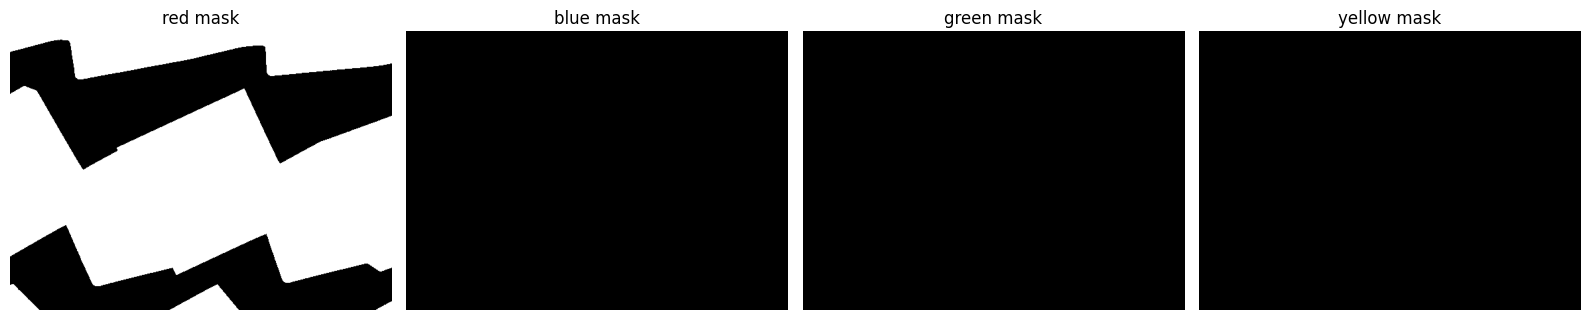

In [8]:
import pandas as pd

mask_results = []
mask_images = {}
total_pixels = hsv_roi.shape[0] * hsv_roi.shape[1]

for color_name, ranges in color_ranges.items():
    mask = classifier._create_color_mask(hsv_roi, ranges)
    count = int(cv2.countNonZero(mask))
    ratio = count / total_pixels if total_pixels > 0 else 0.0
    mask_images[color_name] = mask
    mask_results.append({"color": color_name, "pixel_count": count, "ratio": ratio})

df_scores = pd.DataFrame(mask_results).sort_values("ratio", ascending=False).reset_index(drop=True)
display(df_scores)

n = len(mask_images)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, (name, mask) in zip(axes, mask_images.items()):
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"{name} mask")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9) classify() ile Nihai Renk Tahmini

`classifier.classify(image, bbox)` cagrisi yapilir ve sonuc goruntu uzerine yazdirilir.

[DEBUG] Renk: red (skor: 60.88%, güven: 0.91, H=26)


Tahmin edilen renk: CubeColor.RED
Guven: 0.9132
Dominant H/S/V: 25.73 94.49 190.07


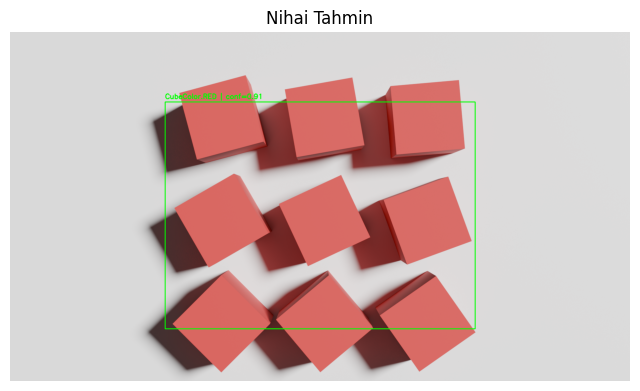

In [9]:
result = classifier.classify(image_bgr, bbox)

print("Tahmin edilen renk:", result.color)
print("Guven:", round(result.confidence, 4))
print("Dominant H/S/V:", round(result.dominant_hue or 0, 2), round(result.dominant_saturation or 0, 2), round(result.dominant_value or 0, 2))

annotated = image_rgb.copy()
cv2.rectangle(annotated, (bbox.x1, bbox.y1), (bbox.x2, bbox.y2), (0, 255, 0), 2)
text = f"{str(result.color)} | conf={result.confidence:.2f}"
cv2.putText(annotated, text, (bbox.x1, max(20, bbox.y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

plt.figure(figsize=(8, 5))
plt.title("Nihai Tahmin")
plt.imshow(annotated)
plt.axis("off")
plt.show()

## 10) Esik Parametreleriyle Canli Deneyler (Slider/What-if)

`ipywidgets` ile esik parametrelerini degistirip sonucun nasil degistigini canli izleyebilirsiniz.

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    out = widgets.Output()

    s_sat = widgets.IntSlider(value=min_saturation, min=0, max=255, step=1, description="min_sat")
    s_val = widgets.IntSlider(value=min_value, min=0, max=255, step=1, description="min_val")
    s_ratio = widgets.FloatSlider(value=min_pixel_ratio, min=0.0, max=1.0, step=0.01, description="min_ratio")
    s_center = widgets.FloatSlider(value=center_region_ratio, min=0.2, max=1.0, step=0.05, description="center")

    def _update(*_):
        with out:
            clear_output(wait=True)
            local_classifier = HSVColorClassifier(
                color_ranges=color_ranges,
                use_center_region=True,
                center_region_ratio=s_center.value,
                apply_clahe_preprocessing=True,
                clahe_clip_limit=clahe_clip_limit,
                clahe_grid_size=clahe_grid_size,
                min_saturation=s_sat.value,
                min_value=s_val.value,
                min_pixel_ratio=s_ratio.value,
            )
            local_result = local_classifier.classify(image_bgr, bbox)
            print(f"color={local_result.color}, confidence={local_result.confidence:.3f}")

    for wdg in [s_sat, s_val, s_ratio, s_center]:
        wdg.observe(_update, names="value")

    controls = widgets.VBox([s_sat, s_val, s_ratio, s_center])
    display(controls, out)
    _update()
except Exception as e:
    print("ipywidgets kullanilamadi:", e)
    print("Calistirmak icin: pip install ipywidgets")

ipywidgets kullanilamadi: No module named 'ipywidgets'
Calistirmak icin: pip install ipywidgets


## 11) Hata Ayiklama Ciktilari ve Ara Sonuclarin Kaydi

DEBUG loglarini gorunur tutar, ara gorselleri `outputs/` klasorune kaydeder ve dosya yolunu dogrular.

In [ ]:
logger.debug("Notebook debug modu aktif")
assert TEST_IMAGE_PATH.exists(), f"Girdi resmi yok: {TEST_IMAGE_PATH}"

outputs_dir = PROJECT_ROOT / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

cv2.imwrite(str(outputs_dir / "step_roi_full.png"), roi_full)
cv2.imwrite(str(outputs_dir / "step_roi_center.png"), roi_center)
cv2.imwrite(str(outputs_dir / "step_roi_clahe.png"), roi_after)
for name, mask in mask_images.items():
    cv2.imwrite(str(outputs_dir / f"step_mask_{name}.png"), mask)

print(f"Ara ciktilar kaydedildi: {outputs_dir}")
print("Notebook hucre sirasi: 1 -> 11, tekrar calistirilabilir.")

## Ozet

Bu notebook ile:
- `test.png` yukuyleme ve bbox secimini,
- ROI ve CLAHE etkisini,
- HSV dominant degerlerini,
- Renk maskesi oranlarini,
- `classify()` ciktilarini,
- slider ile what-if analizini
canli olarak adim adim test edebilirsiniz.